In [10]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

import sys, json
sys.path.append('..')

from models.nist.refractive_index import ciddor, edlen
from models.mathar.Mathar2007 import n

pub_gray = '#cecece'
pub_purple = '#a559aa'
pub_teal = '#59a89c'
pub_gold = '#f0c571'
pub_red = '#e02b35'
pub_blue = '#082a54'

colorlist = [pub_purple, pub_teal, pub_gold, pub_red, pub_blue]


def load_regression_results(filename='regression_results.json'):
    """
    Load regression analysis results from a JSON file.
    
    Parameters
    ----------
    filename : str, optional
        Path to the JSON file containing regression results (default: 'regression_results.json')
    
    Returns
    -------
    dict
        Dictionary containing regression coefficients, standard errors, and other results
    
    Notes
    -----
    The JSON file should contain the output from regression analysis including:
    - Coefficients (const, temperature, humidity, pressure)
    - Standard errors (OLS, HAC, Prais-Winsten)
    - Bootstrap confidence intervals
    - EIV systematic errors
    """
    with open(filename, 'r', encoding='utf-8') as f:
        results = json.load(f)
    print(f"Results loaded from {filename}")
    return results

def refractive_function(results_json):
    """Create prediction function from JSON coefficients"""
    coeff = results_json['coefficients']
    
    def n_1762(T, H, P):
        """
        Predict refractive index at 1762nm using coefficients from JSON
        
        Parameters:
        -----------
        T : float or array
            Temperature in °C
        H : float or array
            Humidity in %
        P : float or array
            Pressure in Pa
            
        Returns:
        --------
        float or array
            Predicted refractive index
        """
        return (coeff['const'] + 
                coeff['temperature'] * T + 
                coeff['humidity'] * H + 
                coeff['pressure'] * P)
    
    return n_1762

In [11]:
results_json = load_regression_results('regression_results.json')
n_1762 = refractive_function(results_json)

Results loaded from regression_results.json


Temperature coefficient (dN/dT):
Ciddor@1700nm: -8.879e-07
Edlen@1700nm: -8.879e-07
Mathar@1762nm: -8.895e-07
This Work@1762nm: -8.847e-07

Humidity coefficient (dN/dH):
Ciddor@1700nm: -8.765e-09
Edlen@1700nm: -8.694e-09
Mathar@1762nm: -1.122e-08
This Work@1762nm: -1.315e-08

Pressure coefficient (dN/dP):
Ciddor@1700nm: 2.650e-09
Edlen@1700nm: 2.650e-09
Mathar@1762nm: 2.650e-09
This Work@1762nm: 2.595e-09


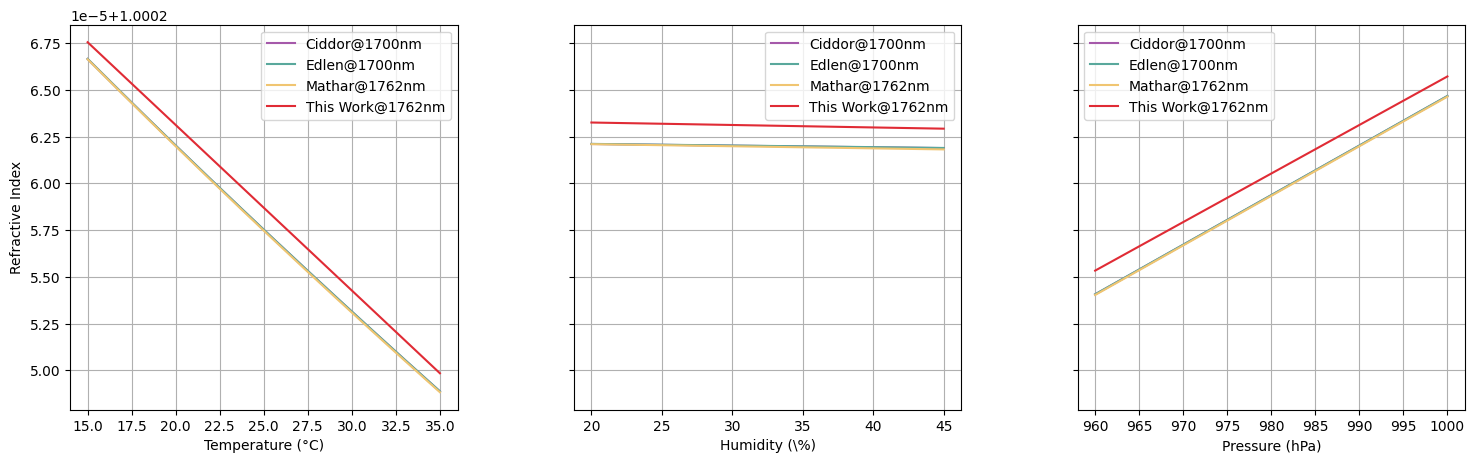

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plt.subplots_adjust(wspace=0.3)

pressure1 = 99000
humidity1 = 30
temperature1 = np.linspace(15, 35, 1000)

models_temp = {
    'Ciddor@1700nm': np.array([ciddor(wave=1762, t=i, p=pressure1, rh=humidity1) for i in temperature1]),
    'Edlen@1700nm': np.array([edlen(wave=1762, t=i, p=pressure1, rh=humidity1) for i in temperature1]),
    'Mathar@1762nm': n(1.762, 273.15+temperature1, pressure1, humidity1),
    'This Work@1762nm': n_1762(temperature1, humidity1, pressure1)
}

for data_info, color in zip(models_temp.items(), colorlist):
    label, values = data_info
    axes[0].plot(temperature1, values, color=color, label=label)
    
print("Temperature coefficient (dN/dT):")
for label, values in models_temp.items():
    slope, _ = np.polyfit(temperature1, values, 1)
    print(f"{label}: {slope:.3e}")

axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Refractive Index')
# axes[0].set_title('Temperature Comparison')
axes[0].grid(True)

pressure2 = 99000
humidity2 = np.linspace(20, 45, 1000)
temperature2 = 20

models_humidity = {
    'Ciddor@1700nm': np.array([ciddor(wave=1762, t=temperature2, p=pressure2, rh=i) for i in humidity2]),
    'Edlen@1700nm': np.array([edlen(wave=1762, t=temperature2, p=pressure2, rh=i) for i in humidity2]),
    'Mathar@1762nm': n(1.762, 273.15+temperature2, pressure2, humidity2),
    'This Work@1762nm': n_1762(temperature2, humidity2, pressure2)
}

for data_info, color in zip(models_humidity.items(), colorlist):
    label, values = data_info
    axes[1].plot(humidity2, values, color=color, label=label)
    
print("\nHumidity coefficient (dN/dH):")
for label, values in models_humidity.items():
    slope, _ = np.polyfit(humidity2, values, 1)
    print(f"{label}: {slope:.3e}")

axes[1].set_xlabel('Humidity (\%)')
# axes[1].set_title('Humidity Comparison')
axes[1].grid(True)

pressure3 = np.linspace(96000, 100000, 1000)
humidity3 = 30
temperature3 = 20

models_pressure = {
    'Ciddor@1700nm': np.array([ciddor(wave=1762, t=temperature3, p=i, rh=humidity3) for i in pressure3]),
    'Edlen@1700nm': np.array([edlen(wave=1762, t=temperature3, p=i, rh=humidity3) for i in pressure3]),
    'Mathar@1762nm': n(1.762, 273.15+temperature3, pressure3, humidity3),
    'This Work@1762nm': n_1762(temperature3, humidity3, pressure3)
}

for data_info, color in zip(models_pressure.items(), colorlist):
    label, values = data_info
    axes[2].plot(pressure3*1e-2, values, color=color, label=label)
    
print("\nPressure coefficient (dN/dP):")
for label, values in models_pressure.items():
    slope, _ = np.polyfit(pressure3, values, 1)
    print(f"{label}: {slope:.3e}")

axes[2].set_xlabel('Pressure (hPa)')
# axes[2].set_title('Pressure Comparison')
axes[2].grid(True)

for ax in axes:
    ax.legend()

plt.show()